In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial, eval_hermite
from numpy.polynomial.hermite import hermgauss
from qutip import (basis, squeeze, tensor, sigmax, sigmay, 
                   identity, destroy, displace)
from scipy.special import gammaln


In [2]:
def get_lchs_states(beta, r_target, r_prime, N_dim, n_quad_points=200):
    """
    Calculates the LCHS coefficients C_n using Gauss-Hermite quadrature.
    Corrects for the normalization factor via explicit state normalization.
    """
    print(f"1. Preparing States (N={N_dim}, r_target={r_target})...")
    # 1. Parameters
    gamma = np.exp(-2 * r_prime) - np.exp(-2 * r_target)
    width_param = np.exp(r_prime) 
    scale_factor = np.sqrt(2) * width_param

    # 2. Quadrature Setup (Integration over x)
    x_roots, weights = hermgauss(n_quad_points) 
    # Map roots to physical variable p (or x in the integral)
    p_points = x_roots * scale_factor

    # 3. Target Function Evaluation g(x)
    # The LCHS target function for the wave equation/CHO
    C_val = 2 * np.pi * np.exp(-2 * beta)
    term_exp = np.exp((1 + 1j * p_points)**beta)
    denom_func = C_val * term_exp * (1 - 1j * p_points)
    
    # We integrate Target(p) * Basis(p). 
    # The weight w_i implicitly includes e^{-x^2}, which cancels the basis Gaussian.
    # We only include the 'excess' Gaussian decay e^{-gamma x^2} from the target.
    target_part = np.exp(-gamma * p_points**2) / denom_func

    # 4. Expansion Coefficients C_n
    cn_list = []
    sqrt_pi = np.sqrt(np.pi)
    basis_prefactor = 1.0 / np.sqrt(sqrt_pi * width_param)

    for n in range(N_dim):
        # fock_norm = 1.0 / np.sqrt((2**n) * factorial(n))
        fock_norm = np.exp(-0.5*(n*np.log(2) + gammaln(n+1)))
        H_val = eval_hermite(n, p_points / width_param)
        
        # Integral: Sum weighted points * Jacobian
        integrand = target_part * (basis_prefactor * fock_norm * H_val)
        val = np.sum(weights * integrand) * scale_factor
        cn_list.append(val)

    # 5. Construct QuTiP Objects
    cn_array = np.array(cn_list)
    psi_seed = sum([cn_array[n] * basis(N_dim, n) for n in range(N_dim)]).unit()

    # Apply Squeezing (Basis Transform)
    S_op_prime = squeeze(N_dim, r_prime)
    psi_osc_init = S_op_prime * psi_seed 

    displacement = 0
    D_op = displace(N_dim, displacement)
    psi_osc_init = D_op * psi_osc_init

    # Post-Selection State (Target Squeezed State)
    S_op_target = squeeze(N_dim, r_target)
    phi_post = S_op_target * basis(N_dim, 0)
    
    # phi_post = D_op * phi_post

    print("   States ready.")
    return psi_osc_init, phi_post

In [3]:
def run_simulation(omega, gamma, T_step, n_steps, N_dim, psi_osc_init, phi_post):
    """
    Runs the simulation and extracts both Position (|0>) and Velocity (|1>) components.
    """
    print("2. Running Simulation...")
    
    # --- Hamiltonian Setup ---
    # These coefficients couple |0> <-> |1> (Pos <-> Vel)
    # Standard mapping for wave eq: du/dt = w*v, dv/dt = -w*u

    L_coeff = 0.5 * gamma
    H_coeff = -omega

    Op_L = L_coeff * identity(2)   # PSD: eigenvalues = gamma/2 >= 0
    Op_H = H_coeff * sigmay()      # rotation generator

    a = destroy(N_dim)
    # computational momentum/position operator for the auxiliary space
    K_op = (a.dag() + a) / 2
    
    kappa = phi_post.dag() * K_op * psi_osc_init
    print(kappa)

    Id_osc = identity(N_dim)
    Ham_Joint = tensor(K_op, Op_L)
    Ham_Single = tensor(Id_osc, Op_H)
    
    # Trotter Evolution Step
    U_joint = (-1j * T_step * Ham_Joint).expm()
    U_single = (-1j * T_step * Ham_Single).expm()
    U_step = U_joint * U_single

    # --- Initial State ---
    # Start qubit in |0> (Position = 1, Velocity = 0)
    psi_qubit_0 = basis(2, 0)
    psi_current = tensor(psi_osc_init, psi_qubit_0)
    
    # Projector to extract qubit state from the joint system
    # We project the oscillator onto <phi_post|
    projector_osc_bra = tensor(phi_post.dag(), identity(2))

    # --- Data Collection ---
    u_vals = [] # Position (Real part of |0>)
    v_vals = [] # Velocity (Imag part of |1> or similar depending on encoding)
    times = np.linspace(0, n_steps * T_step, n_steps)

    # Calculate Normalization Factor from t=0
    vec_0 = (projector_osc_bra * psi_current).full()
    norm_factor = np.linalg.norm(vec_0)
    print(f"   Normalization Factor: {norm_factor:.4f}")

    for _ in range(n_steps):
        # 1. Project out the oscillator part -> get 2x1 qubit vector
        qubit_vec = (projector_osc_bra * psi_current).full()

        # step_norm = np.linalg.norm(qubit_vec)
        
        u_t = np.real(qubit_vec[0][0])
        v_t = np.real(qubit_vec[1][0])

        # print(f"   t={_:3d} | Norm={step_norm:.4f} | u={u_t:.4f}+{np.imag(u_amp):.4f}j | v={v_t:.4f}+{np.imag(v_amp):.4f}j")
# compare v_amp.imag or a scaled version to -sin(ωt)


        u_vals.append(u_t)
        v_vals.append(v_t)
        
        # 3. Evolve
        psi_current = U_step * psi_current
        
    return times, u_vals, v_vals

In [4]:
def main():
    # Parameters
    omega = 10.0
    beta = 0.8
    r_target = 8
    r_prime = 6
    N_dim = 100
    T_step = 0.05
    n_steps = 100

    # 1. Prepare
    psi_init, phi_post = get_lchs_states(beta, r_target, r_prime, N_dim)
    
    # 2. Run
    gamma = 0.2  # try 0.05, 0.1, 0.2, 0.5
    times, u_vals, v_vals = run_simulation(omega, gamma, T_step, n_steps, N_dim, psi_init, phi_post)

    # 3. Classical Solution (CHO)
    # Initial Conditions: u(0)=1, v(0)=0 (implied by starting qubit in |0>)
    # u(t) = cos(wt)
    # v(t) = -sin(wt) * (scaling factor)
    # Note: LCHS mapping often implies v_physical = -omega * u_qubit_1
    # omega = 0.5 * (omega **2  + 1)
    exact_u = np.exp(-0.5 * gamma * times) * np.cos(omega * times)
    exact_v = -np.exp(-0.5 * gamma * times) * np.sin(omega * times)

    # 4. Visualization

    # The quantum state effectively sees this frequency because <K> = 0
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)

    # Position Plot
    plt.plot(times, u_vals, 'b.-', label='LCHS (Qubit |0>)', linewidth=2)
    plt.plot(times, exact_u, 'k--', label='Classical cos($\\omega$t)', alpha=0.6)
    plt.title("Position $u(t)$")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Velocity Plot
    plt.subplot(2, 1, 2)
    plt.plot(times, v_vals, 'r.-', label='LCHS (Qubit |1>)', linewidth=2)

    plt.plot(times, exact_v, 'k--', label='Classical -sin($\\omega$t)', alpha=0.6)
        
    plt.title("Velocity $v(t)$")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

1. Preparing States (N=100, r_target=8)...
   States ready.
2. Running Simulation...
-0.8764323165640427j
   Normalization Factor: 0.8132


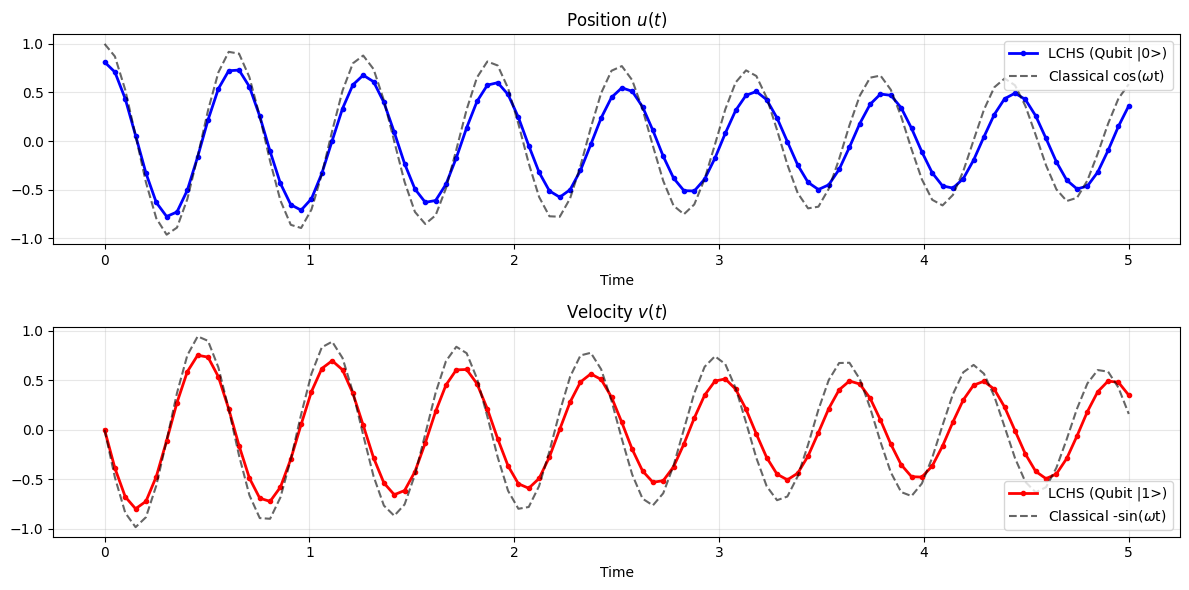

In [5]:
if __name__ == "__main__":
    main()